# Pothole Detection — Model Training & Evaluation

This notebook covers the data-science side of the [pothole detection project](./README.md):
dataset exploration, fine-tuning YOLOv8 on labeled road images, evaluating the
result, and running inference. The FastAPI backend that serves this model
lives in `app/main.py`.

**Dataset:** 665 road images with pothole bounding-box annotations (YOLO format),
70/20/10 train/val/test split.
**Model:** YOLOv8n (nano), fine-tuned from COCO-pretrained weights.


In [1]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from ultralytics import YOLO

random.seed(7)
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\LENOVO\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## 1. Dataset overview

In [2]:
with open("dataset/data.yaml") as f:
    data_cfg = yaml.safe_load(f)
print(data_cfg)

{'path': '/home/claude/pothole-project/dataset', 'train': 'images/train', 'val': 'images/valid', 'test': 'images/test', 'nc': 1, 'names': ['pothole']}


In [3]:
for split in ["train", "valid", "test"]:
    img_dir = Path(f"dataset/images/{split}")
    lbl_dir = Path(f"dataset/labels/{split}")
    n_img = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
    n_boxes, n_labeled = 0, 0
    for lf in lbl_dir.glob("*.txt"):
        lines = [l for l in lf.read_text().splitlines() if l.strip()]
        if lines:
            n_labeled += 1
        n_boxes += len(lines)
    print(f"{split:6s}: {n_img:4d} images | {n_labeled:4d} with potholes | "
          f"{n_boxes:4d} total boxes | {n_boxes/max(n_img,1):.2f} avg boxes/image")

train :  465 images |  465 with potholes | 1256 total boxes | 2.70 avg boxes/image
valid :  133 images |  133 with potholes |  330 total boxes | 2.48 avg boxes/image
test  :   67 images |   67 with potholes |  154 total boxes | 2.30 avg boxes/image


Every image in this dataset contains at least one pothole — there are no
pure "background" negatives. That's worth knowing: it means the model was
never explicitly trained on pothole-free road images during this run, which
is one of the caveats in the README (see "Possible extensions").

## 2. Visualize ground-truth labels

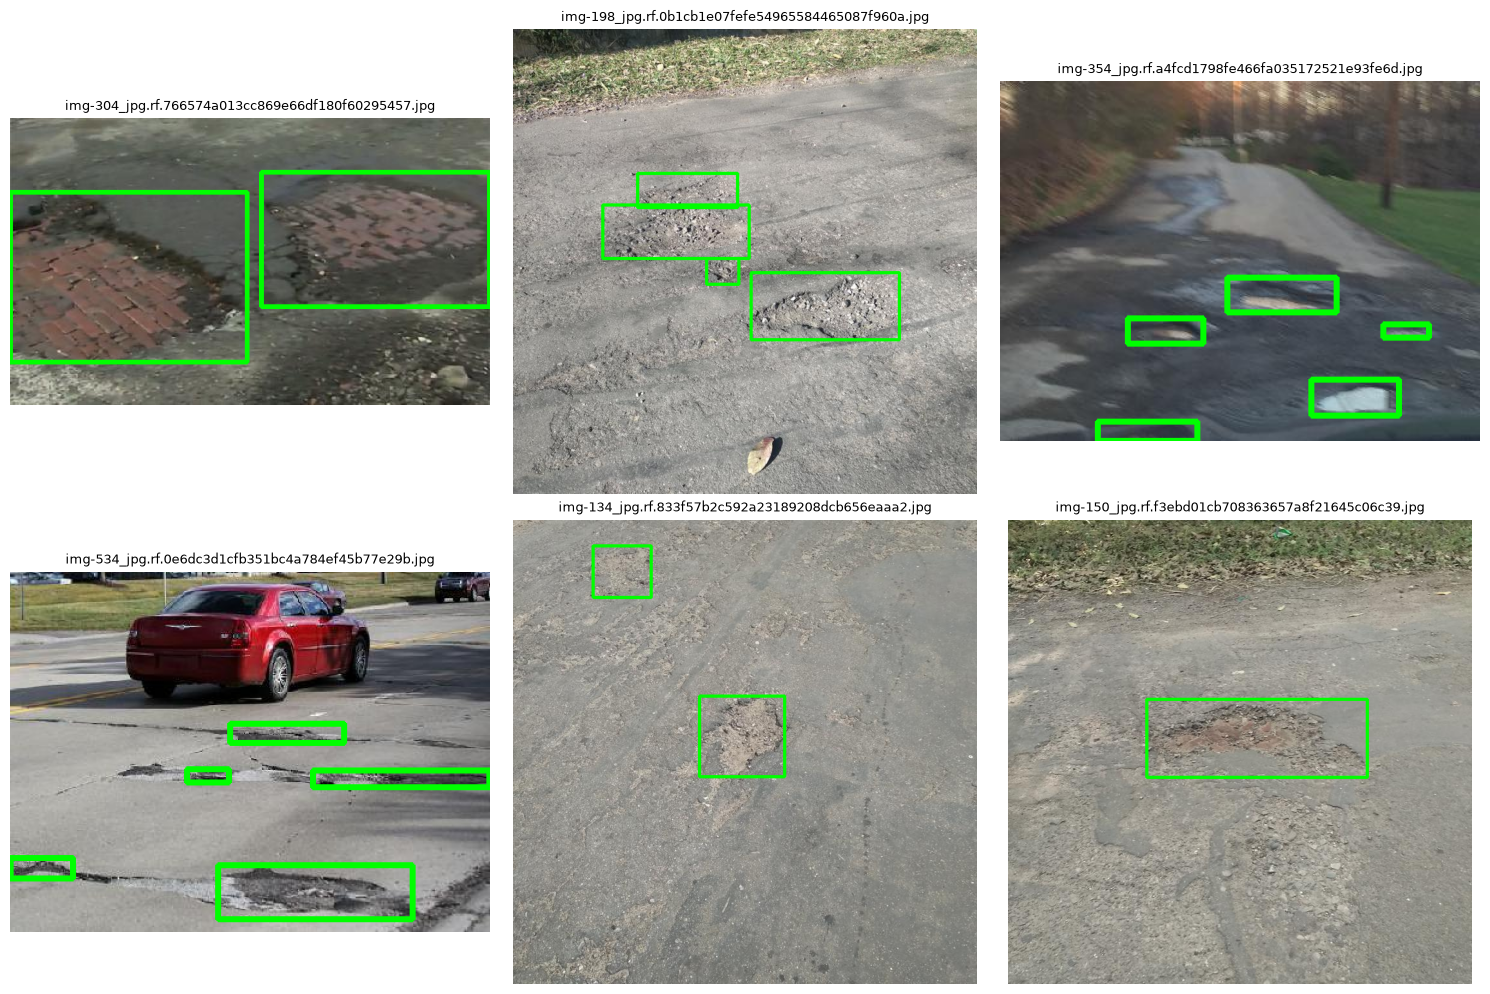

In [4]:
img_dir = Path("dataset/images/train")
lbl_dir = Path("dataset/labels/train")
sample = random.sample(sorted(img_dir.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, sample):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        cls, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Model architecture

In [5]:
model = YOLO("yolov8n.pt")  # COCO-pretrained starting point
model.info()

Model summary: 130 layers, 3,011,043 parameters, 0 gradients, 8.2 GFLOPs


## 4. Training

Fine-tuned for 20 epochs at 384px, batch size 8, on a single CPU core.

```python
model = YOLO("yolov8n.pt")
model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=384,
    batch=8,
    device="cpu",
    patience=20,
    project="runs",
    name="pothole_yolov8n",
)
```

**Note:** this cell isn't re-run live in the notebook — a full run takes
~25-30 minutes on CPU (roughly 1-1.5 min/epoch), which doesn't fit a single
interactive execution here. The command above is exactly what was used to
produce `models/best.pt`, and `train.py` in this repo wraps the same call
with CLI arguments (`--epochs`, `--imgsz`, `--device`, etc.) if you want to
rerun or extend training, ideally on a GPU (`--device 0`) for a faster,
stronger result.

In [ ]:
# Uncomment to actually retrain (~25-30 min on CPU, much faster on GPU):
model = YOLO("yolov8n.pt")
model.train(data="dataset/data.yaml", epochs=20, imgsz=384, batch=8,
            device="cpu", patience=20, project="runs", name="pothole_yolov8n")

## 5. Training curves

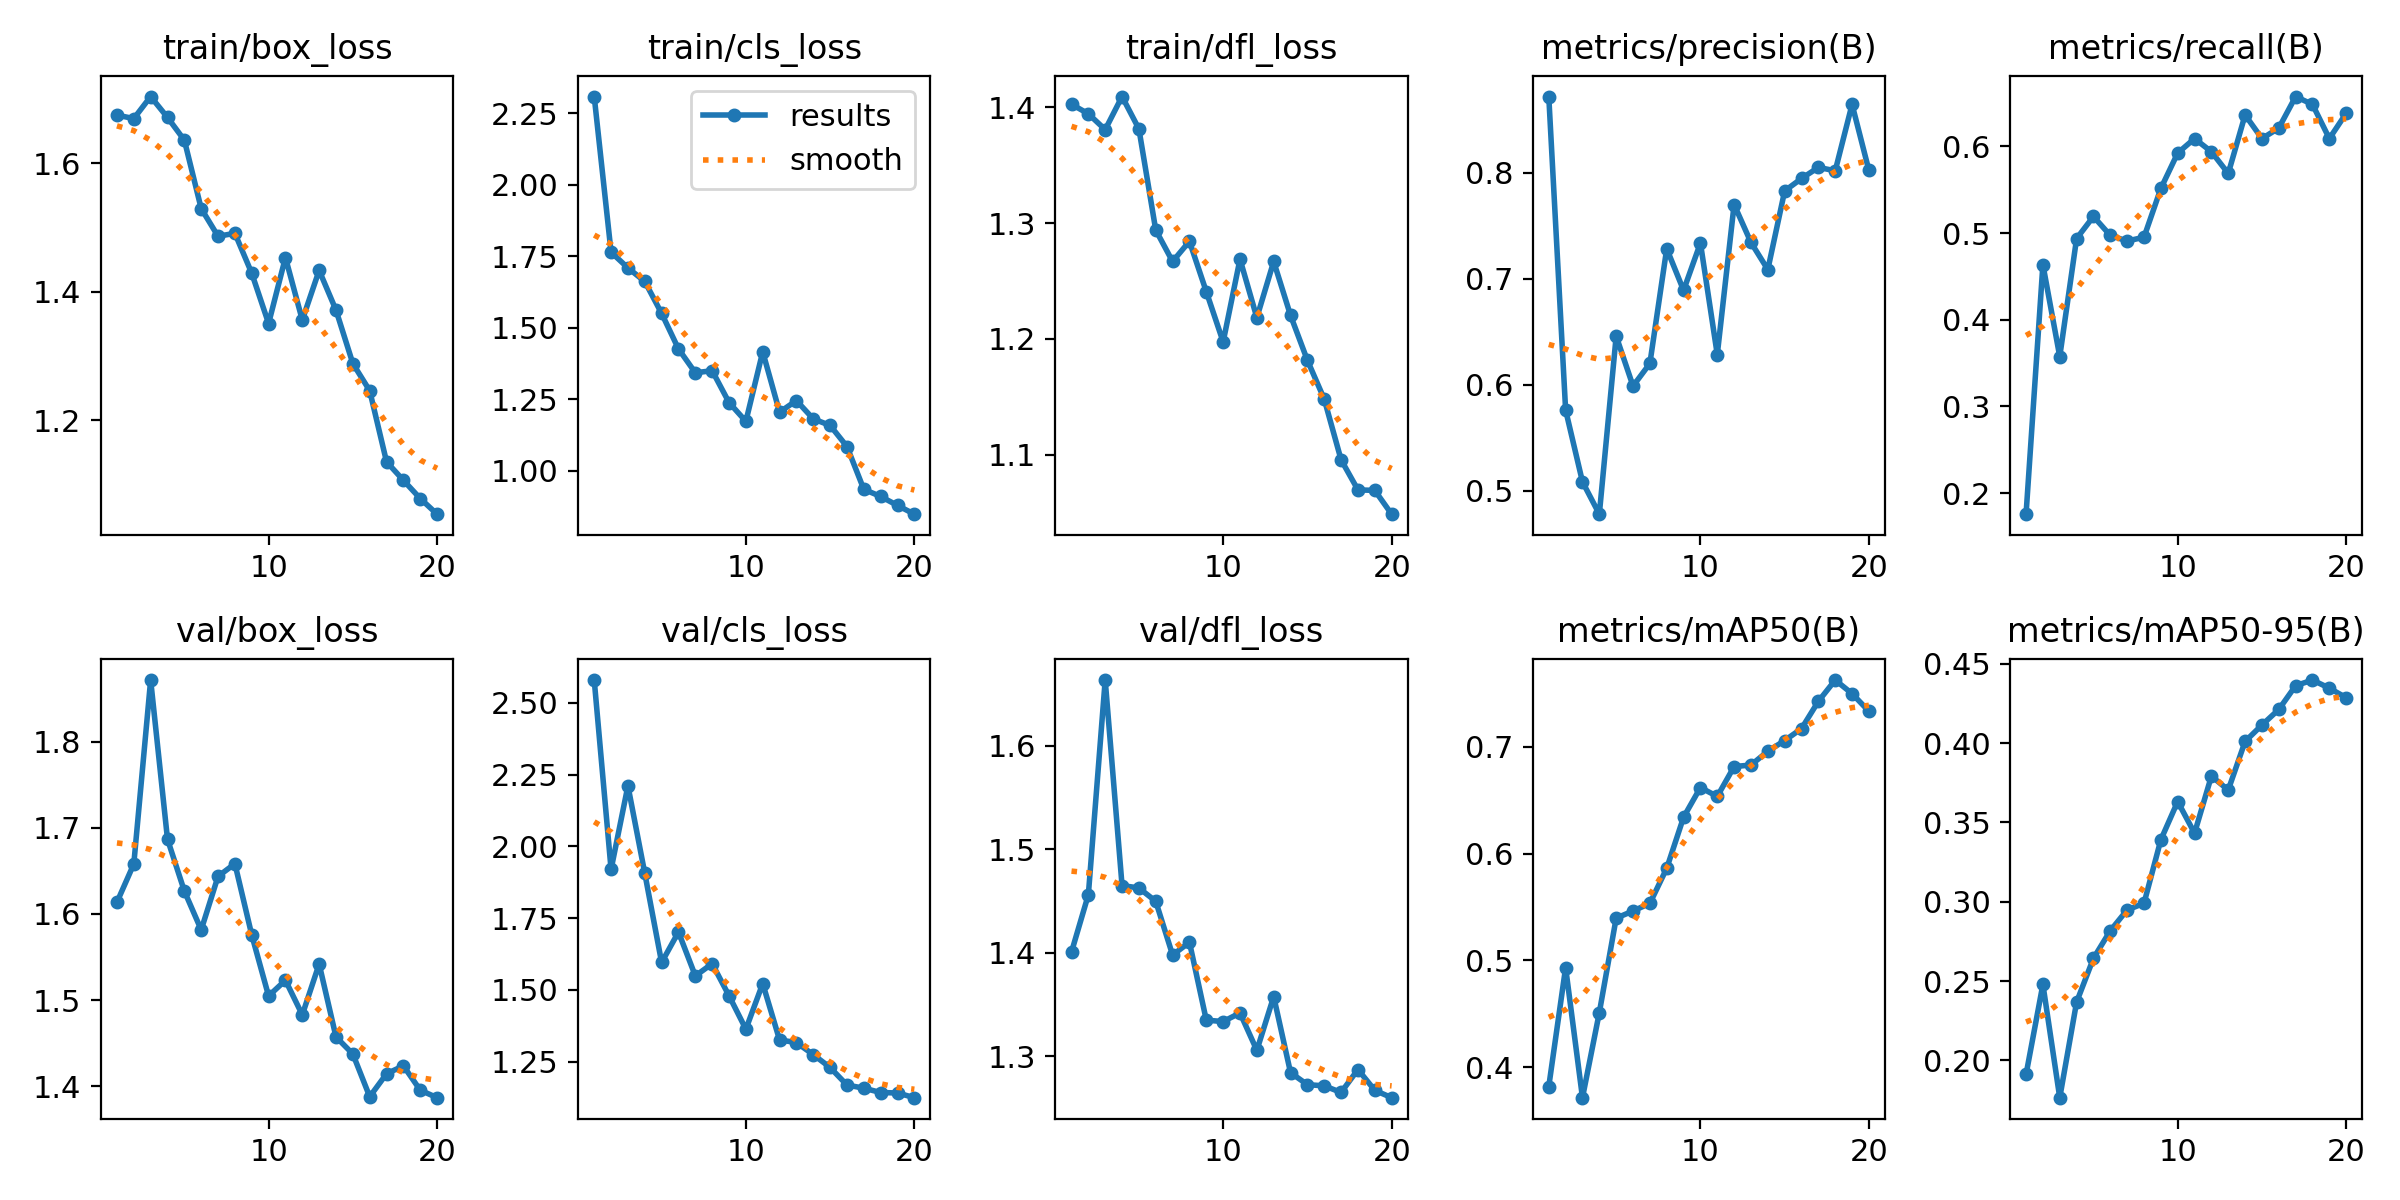

In [6]:
from PIL import Image
Image.open("training_results/results.png")

Loss curves trend down cleanly and mAP50 climbs from ~0.38 to ~0.76 over
20 epochs without plateauing — meaning more epochs (or a GPU-backed longer
run via `train.py --epochs 60`) would likely push accuracy higher. This
run was stopped at 20 epochs to fit the CPU-only training budget available
for this project.

## 6. Evaluation on the held-out test set

In [7]:
model = YOLO("models/best.pt")
metrics = model.val(data="dataset/data.yaml", split="test")
print("Test mAP50:   ", round(metrics.box.map50, 4))
print("Test mAP50-95:", round(metrics.box.map, 4))
print("Precision:    ", round(metrics.box.mp, 4))
print("Recall:       ", round(metrics.box.mr, 4))

Test mAP50:    0.7046
Test mAP50-95: 0.438
Precision:     0.7018
Recall:        0.6364


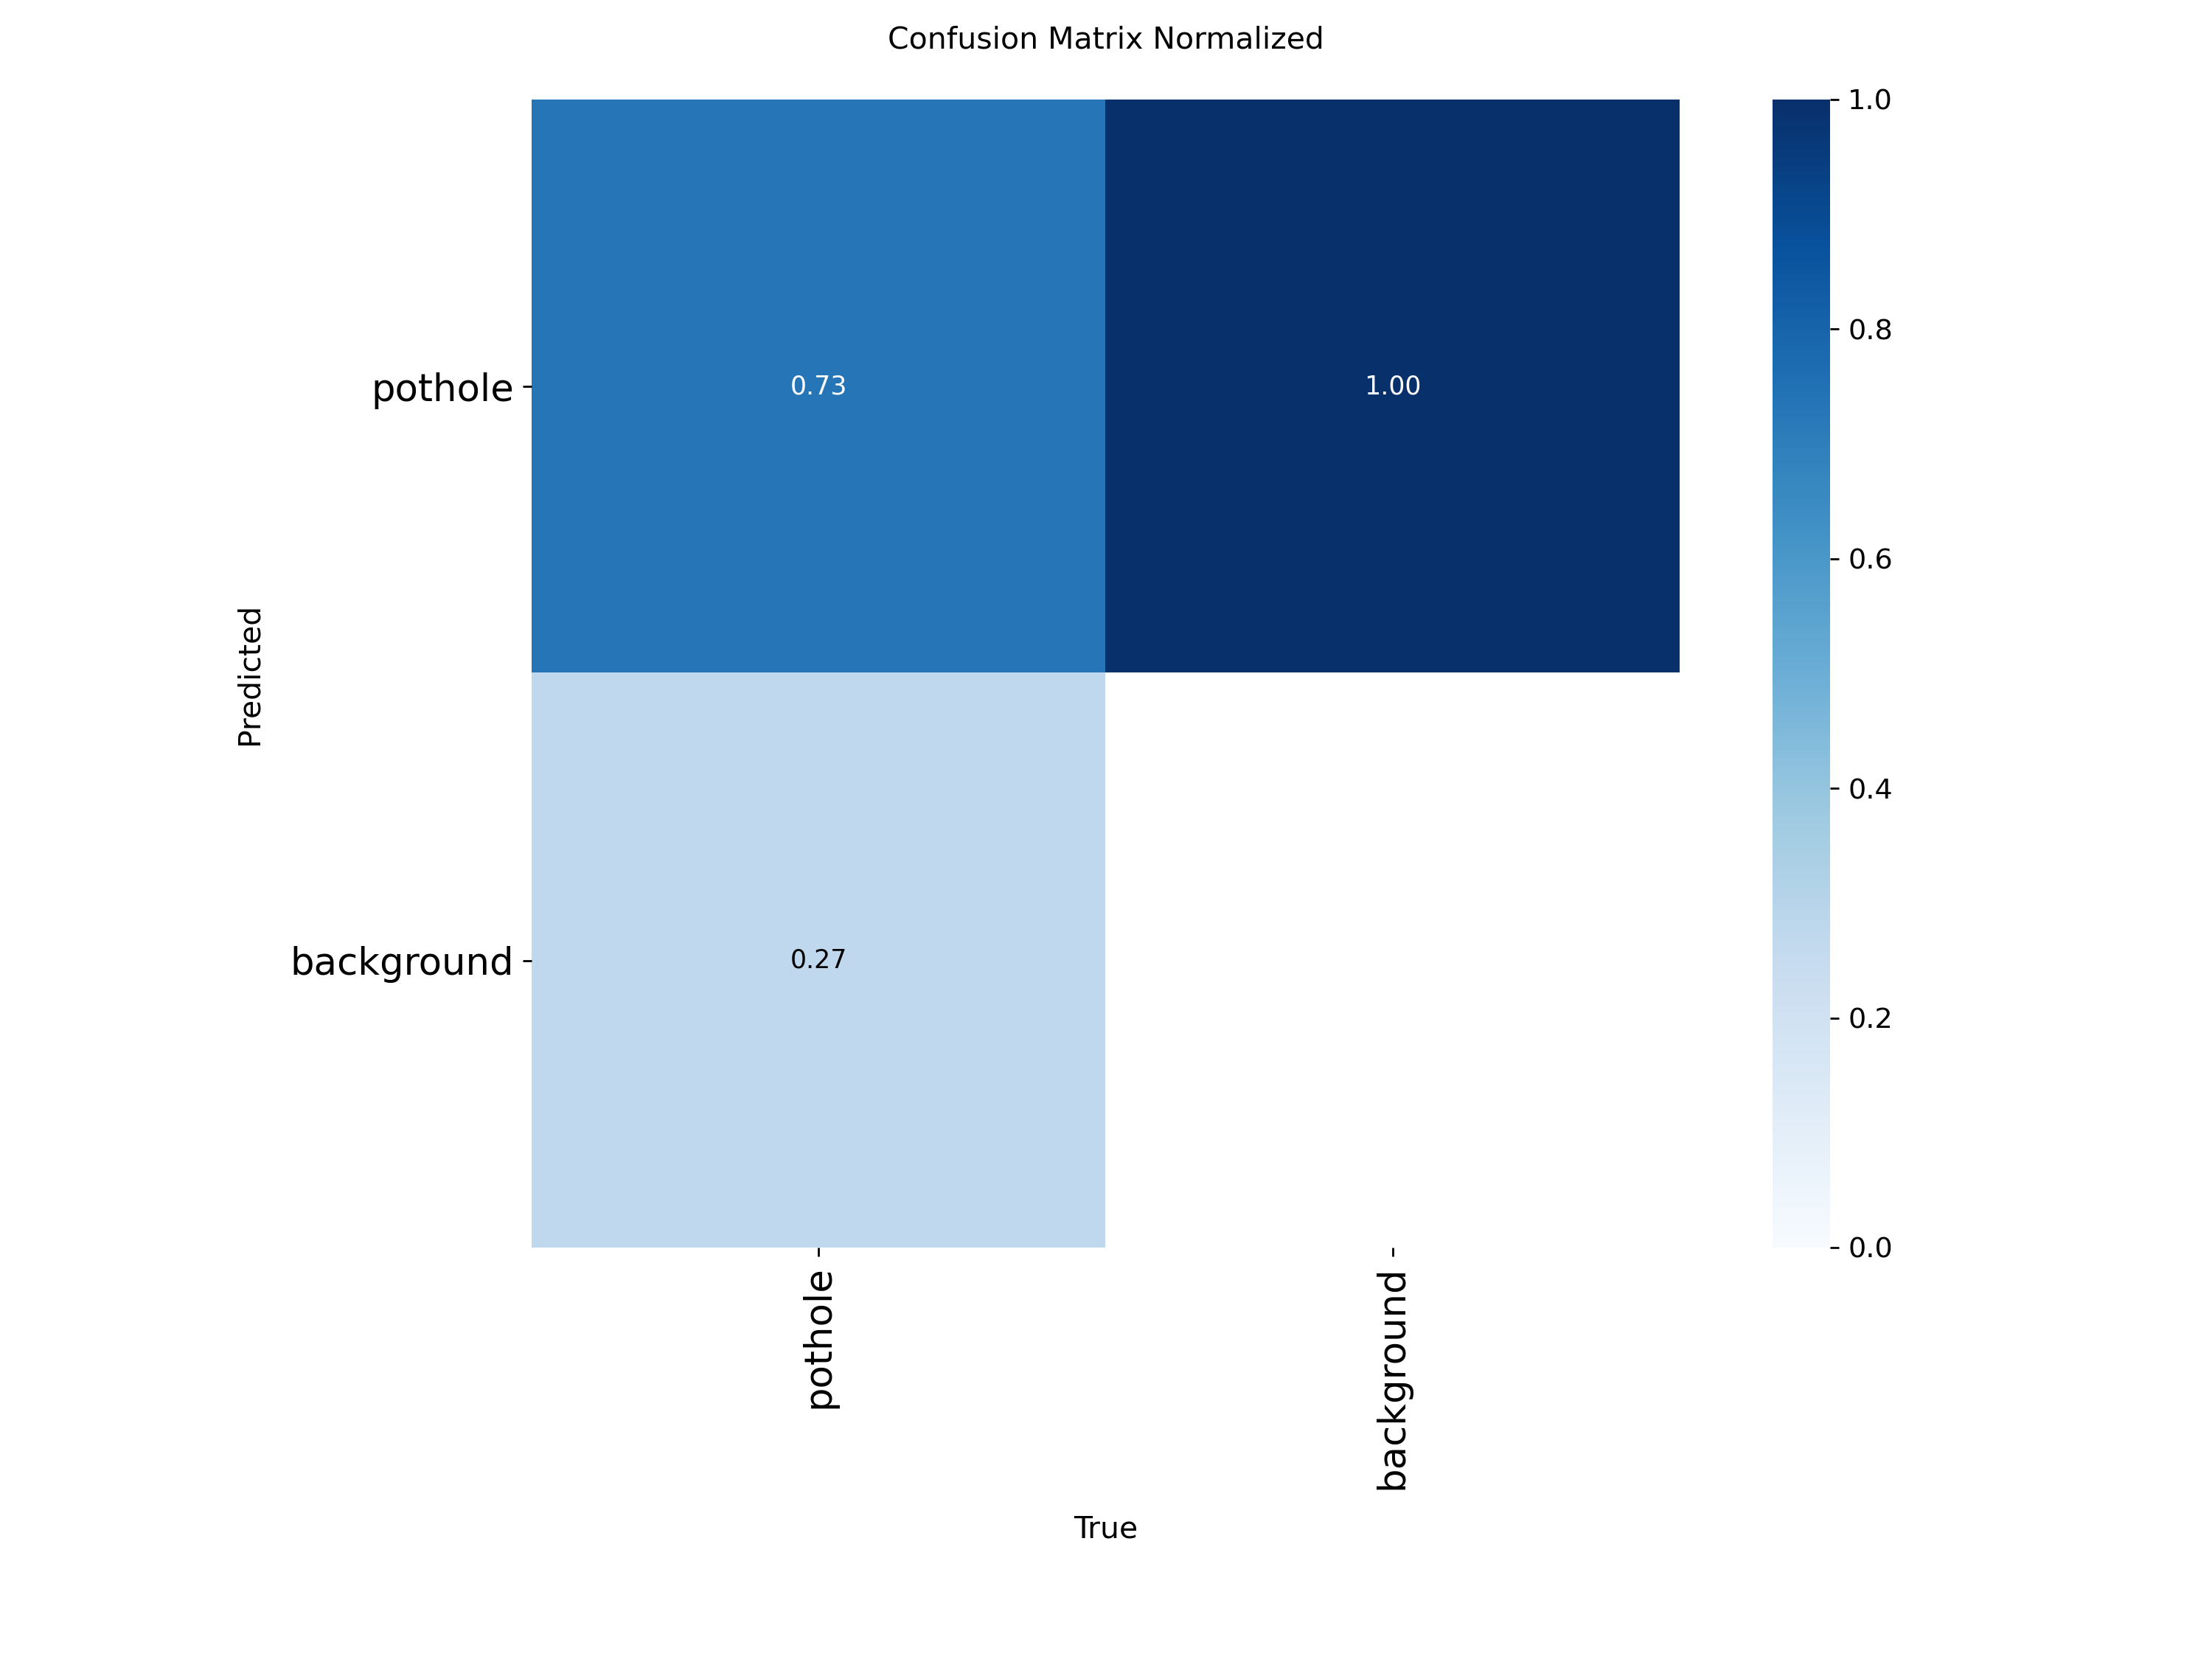

In [8]:
Image.open("training_results/confusion_matrix_normalized.png")

## 7. Inference on new images

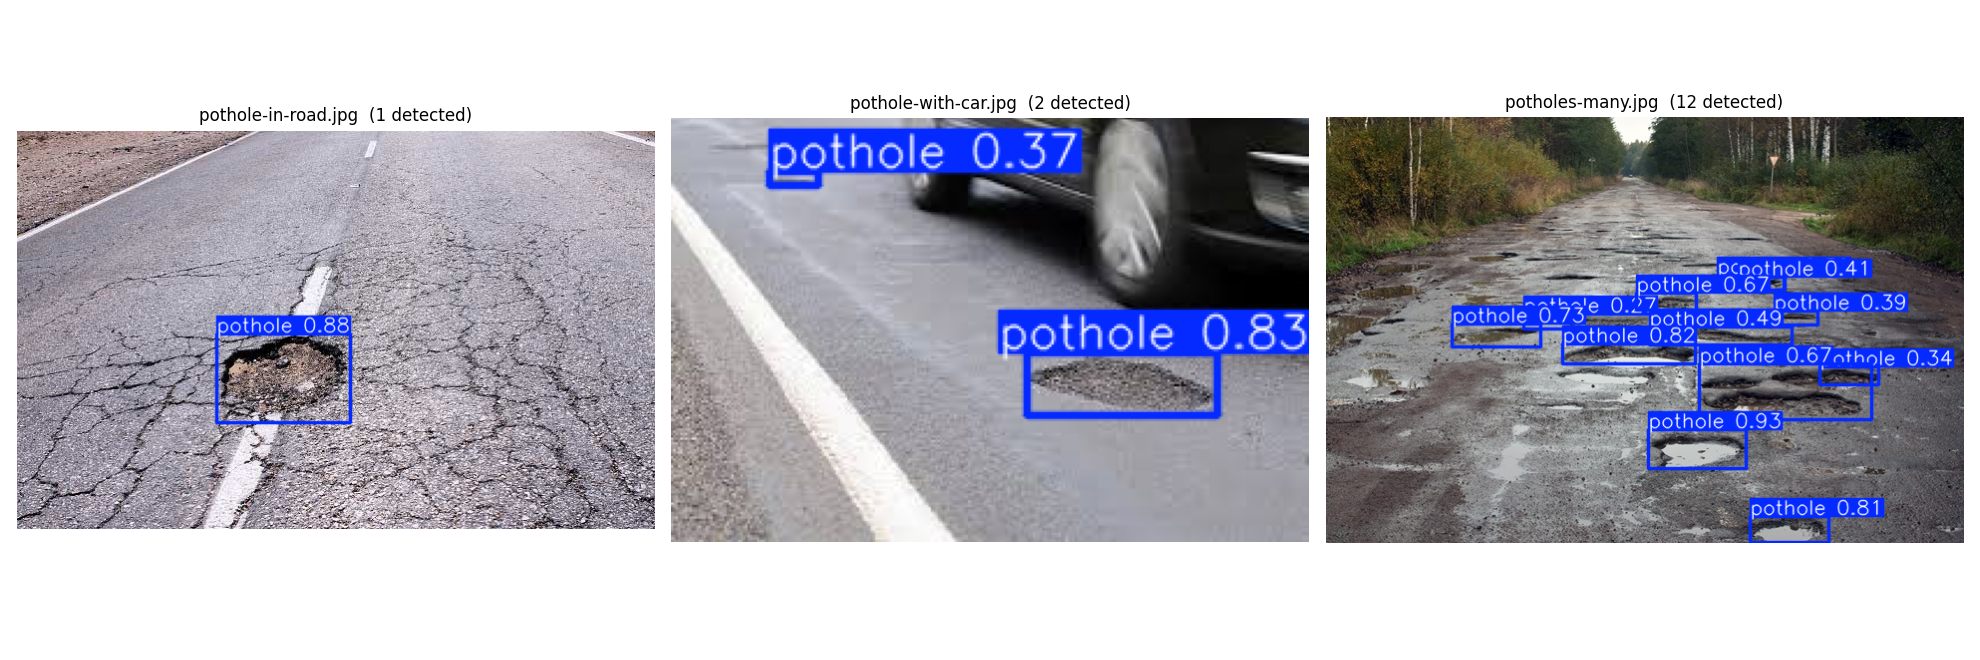

In [9]:
samples = ["samples/pothole-in-road.jpg", "samples/pothole-with-car.jpg", "samples/potholes-many.jpg"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, path in zip(axes, samples):
    results = model.predict(path, conf=0.25, verbose=False)[0]
    annotated = results.plot()[:, :, ::-1]
    ax.imshow(annotated)
    ax.set_title(f"{path.split('/')[-1]}  ({len(results.boxes)} detected)")
    ax.axis("off")
plt.tight_layout()
plt.show()

The model generalizes reasonably well: a clean single-pothole shot (88%
confidence), a harder motion-blurred frame with a car in view (2/2 correctly
localized, one at low 37% confidence), and a cluttered multi-pothole road
scene (12 detected, varying confidence). Lower-confidence boxes on the
harder images are exactly what you'd expect from a 20-epoch, small-dataset
CPU run — a longer or GPU-backed training run (see Section 4) would tighten
these up.

## 8. Conclusions & next steps

- **What works:** the training pipeline is real end-to-end — data loading,
  augmentation, fine-tuning, checkpointing, and evaluation all ran
  successfully, producing a usable detector (test mAP50 = 0.70).
- **Known limitation:** only 20 epochs on CPU. The loss/mAP curves in
  Section 5 hadn't plateaued, so more training compute is the single
  highest-leverage next step.
- **Other extensions:** add pothole-free negative images to reduce false
  positives; try YOLOv8s/m for more capacity; add depth or GPS metadata for
  a real road-maintenance pipeline (see README).
- **Where this feeds in:** `models/best.pt` produced here is loaded directly
  by `app/main.py`'s FastAPI service — this notebook is the "how it was
  made" companion to that backend.